### **This new notebook is for the 8 Features, 1 qubit per feature experiment, in total we have 8 Qubits. This notebook reutilizes a lot of code in QAOA_4F2Q_8Q.ipynb if you want to get a deeper insight you can refer to that notebook is well documented code**

**Imports**

In [1]:
import math
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import kirin
from kirin.dialects import ilist
from bloqade import qasm2
from bloqade.pyqrack import StackMemorySimulator
from scipy.optimize import minimize

**Problem specific Hc, Hm and variables**

In [2]:
# =========================================================
# PROBLEM DEFINITION: 8 assets / 8 qubits
# Corrected Ising Hamiltonian validated against QUBO
# Convention used:
#   QUBO energy = x @ Q @ x + offset
#   x_i = (1 + s_i)/2
# =========================================================

n_qubits = 8

asset_labels = [
    "A017 (Gov Bonds)",
    "A042 (Gov Bonds)",
    "A026 (IG Credit)",
    "A043 (IG Credit)",
    "A007 (Cash)",
    "A048 (Cash)",
    "A047 (HY Credit)",
    "A037 (HY Credit)",
]

# Ground truth from brute force
ground_truth_x = np.array([0, 0, 1, 1, 1, 0, 1, 1], dtype=int)
ground_truth_bits = "".join(map(str, ground_truth_x.tolist()))
ground_truth_energy = -0.019995518790163036

# Corrected Ising local fields h
h_terms = np.array([
    0.058222,
    0.058248,
    0.034039,
    0.033841,
    0.072964,
    0.073309,
    0.015861,
    0.015825,
], dtype=float)

# Corrected Ising couplings J as symmetric matrix
J_terms = np.zeros((n_qubits, n_qubits), dtype=float)

J_terms[0,1] = 0.200016
J_terms[0,2] = 0.120003
J_terms[0,3] = 0.120002
J_terms[0,4] = 0.250002
J_terms[0,5] = 0.250001
J_terms[0,6] = 0.060001
J_terms[0,7] = 0.060003

J_terms[1,2] = 0.120003
J_terms[1,3] = 0.120005
J_terms[1,4] = 0.250000
J_terms[1,5] = 0.250002
J_terms[1,6] = 0.060003
J_terms[1,7] = 0.060003

J_terms[2,3] = 0.072014
J_terms[2,4] = 0.150000
J_terms[2,5] = 0.150000
J_terms[2,6] = 0.036002
J_terms[2,7] = 0.036003

J_terms[3,4] = 0.150000
J_terms[3,5] = 0.150001
J_terms[3,6] = 0.036003
J_terms[3,7] = 0.036003

J_terms[4,5] = 0.312503
J_terms[4,6] = 0.075002
J_terms[4,7] = 0.075002

J_terms[5,6] = 0.075002
J_terms[5,7] = 0.075000

J_terms[6,7] = 0.018016

# Symmetrize
J_terms = J_terms + J_terms.T

ising_offset = 0.595718

print("8Q Hamiltonian loaded.")
print("n_qubits =", n_qubits)
print("ground_truth_bits =", ground_truth_bits)
print("ground_truth_energy =", ground_truth_energy)
print("h_terms shape =", h_terms.shape)
print("J_terms shape =", J_terms.shape)
print("ising_offset =", ising_offset)

8Q Hamiltonian loaded.
n_qubits = 8
ground_truth_bits = 00111011
ground_truth_energy = -0.019995518790163036
h_terms shape = (8,)
J_terms shape = (8, 8)
ising_offset = 0.595718


Freeze Hamiltonian to evade bugs

In [3]:
# =========================================================
# Freeze Hamiltonian ONCE
# This avoids the repeated bug of mixing formats later
# =========================================================

h_base = np.array(h_terms, dtype=float).reshape(-1).copy()
J_base = np.array(J_terms, dtype=float).copy()

assert h_base.shape == (n_qubits,), f"h_base shape inesperada: {h_base.shape}"
assert J_base.shape == (n_qubits, n_qubits), f"J_base shape inesperada: {J_base.shape}"

# Bloqade-friendly structured terms
h_kernel_terms = [(i, float(h_base[i])) for i in range(n_qubits)]
J_kernel_terms = [
    (i, j, float(J_base[i, j]))
    for i in range(n_qubits)
    for j in range(i + 1, n_qubits)
    if abs(J_base[i, j]) > 1e-15
]

print("Frozen h_base shape:", h_base.shape)
print("Frozen J_base shape:", J_base.shape)
print("h_kernel_terms (first 5):", h_kernel_terms[:5])
print("J_kernel_terms (first 10):", J_kernel_terms[:10])
print("Number of J couplings:", len(J_kernel_terms))

Frozen h_base shape: (8,)
Frozen J_base shape: (8, 8)
h_kernel_terms (first 5): [(0, 0.058222), (1, 0.058248), (2, 0.034039), (3, 0.033841), (4, 0.072964)]
J_kernel_terms (first 10): [(0, 1, 0.200016), (0, 2, 0.120003), (0, 3, 0.120002), (0, 4, 0.250002), (0, 5, 0.250001), (0, 6, 0.060001), (0, 7, 0.060003), (1, 2, 0.120003), (1, 3, 0.120005), (1, 4, 0.25)]
Number of J couplings: 28


### **Circuit Builder**

In [4]:
# =========================================================
# QAOA kernel builder for Ising Hamiltonian
# H_C = sum_{i<j} J_ij Z_i Z_j + sum_i h_i Z_i
# H_M = sum_i X_i
# =========================================================

def build_qaoa_ising_kernel(n_qubits, h_terms_struct, J_terms_struct):
    @qasm2.extended
    def kernel(gamma: ilist.IList[float, Any], beta: ilist.IList[float, Any]):
        q = qasm2.qreg(n_qubits)

        # Initial |+>^n
        for i in range(n_qubits):
            qasm2.h(q[i])

        # QAOA layers
        for layer in range(len(gamma)):
            g = gamma[layer]
            b = beta[layer]

            # Cost unitary: local Z terms
            for k in range(len(h_terms_struct)):
                i = h_terms_struct[k][0]
                hi = h_terms_struct[k][1]
                qasm2.rz(q[i], 2.0 * g * hi)

            # Cost unitary: ZZ couplings
            for k in range(len(J_terms_struct)):
                i = J_terms_struct[k][0]
                j = J_terms_struct[k][1]
                Jij = J_terms_struct[k][2]

                qasm2.cx(q[i], q[j])
                qasm2.rz(q[j], 2.0 * g * Jij)
                qasm2.cx(q[i], q[j])

            # Mixer unitary
            for i in range(n_qubits):
                qasm2.rx(q[i], 2.0 * b)

        return q

    return kernel

kernel = build_qaoa_ising_kernel(n_qubits, h_kernel_terms, J_kernel_terms)
print("QAOA kernel built successfully.")

QAOA kernel built successfully.


**Helper Functions and checks**

In [5]:
# =========================================================
# Classical helpers
# =========================================================

def bitstring_from_index(idx, n):
    return format(idx, f"0{n}b")

def bits_to_spin(bitstring):
    return np.array([1 if b == "1" else -1 for b in bitstring], dtype=int)

def ising_energy_from_spin(s, J, h, const_total):
    n = len(s)
    e = const_total

    for i in range(n):
        e += h[i] * s[i]

    for i in range(n):
        for j in range(i + 1, n):
            e += J[i, j] * s[i] * s[j]

    return float(e)

def ising_energy_from_bitstring(bitstring, J, h, const_total):
    s = bits_to_spin(bitstring)
    return ising_energy_from_spin(s, J, h, const_total)

def expected_energy_from_probs(probs, n_qubits, J, h, const_total):
    e_exp = 0.0
    for idx, p in enumerate(probs):
        if p <= 0:
            continue
        bitstring = bitstring_from_index(idx, n_qubits)
        e = ising_energy_from_bitstring(bitstring, J, h, const_total)
        e_exp += p * e
    return float(e_exp)

def probability_of_bitstring(probs, bitstring):
    idx = int(bitstring, 2)
    return float(probs[idx])

def top_bitstring_from_probs(probs, n_qubits):
    idx = int(np.argmax(probs))
    return bitstring_from_index(idx, n_qubits), float(probs[idx])

# Quick sanity check
const_total = ising_offset
gt_energy_check = ising_energy_from_bitstring(ground_truth_bits, J_base, h_base, const_total)

print("Ground truth bits       :", ground_truth_bits)
print("Expected target energy  :", ground_truth_energy)
print("Ising energy check      :", gt_energy_check)
print("Absolute difference     :", abs(gt_energy_check - ground_truth_energy))

Ground truth bits       : 00111011
Expected target energy  : -0.019995518790163036
Ising energy check      : -0.01999799999999988
Absolute difference     : 2.481209836844439e-06


**We create the simulator**

In [6]:
# =========================================================
# Simulator helper
# =========================================================

sim = StackMemorySimulator()

def get_probs_from_kernel(kernel, gamma_vals, beta_vals):
    sv = sim.state_vector(kernel, args=(gamma_vals, beta_vals))
    probs = np.abs(np.asarray(sv)) ** 2
    probs = probs / probs.sum()
    return probs

In [7]:
# =========================================================
# Single-P optimizer runner
# =========================================================

def run_single_qaoa_P(P, optimizer_name="COBYLA", maxiter=200):
    const_total = ising_offset

    def objective(theta):
        gamma_vals = theta[:P].tolist()
        beta_vals = theta[P:].tolist()

        probs = get_probs_from_kernel(kernel, gamma_vals, beta_vals)
        e_exp = expected_energy_from_probs(probs, n_qubits, J_base, h_base, const_total)
        return e_exp

    # simple init
    gamma0 = np.full(P, 0.3, dtype=float)
    beta0 = np.full(P, 0.2, dtype=float)
    x0 = np.concatenate([gamma0, beta0])

    t0 = time.time()
    result = minimize(
        objective,
        x0,
        method=optimizer_name,
        options={"maxiter": maxiter}
    )
    runtime_sec = time.time() - t0

    theta_opt = result.x
    gamma_opt = theta_opt[:P].tolist()
    beta_opt = theta_opt[P:].tolist()

    probs_opt = get_probs_from_kernel(kernel, gamma_opt, beta_opt)
    expected_energy = expected_energy_from_probs(probs_opt, n_qubits, J_base, h_base, const_total)
    gt_prob = probability_of_bitstring(probs_opt, ground_truth_bits)
    top_bitstring, top_probability = top_bitstring_from_probs(probs_opt, n_qubits)

    return {
        "P": P,
        "optimizer": optimizer_name,
        "runtime_sec": float(runtime_sec),
        "best_fun": float(result.fun),
        "expected_energy": float(expected_energy),
        "best_gamma": gamma_opt,
        "best_beta": beta_opt,
        "ground_truth_probability": float(gt_prob),
        "top_bitstring": top_bitstring,
        "top_probability": float(top_probability),
        "probs_opt": probs_opt.copy(),
        "opt_result": result,
    }

In [8]:
# =========================================================
# Multi-P runner
# Start simple: P = 1, 2, 3 with COBYLA
# =========================================================

def run_qaoa_multiP(P_values, optimizer_name="COBYLA", maxiter=200):
    results = []

    for P in P_values:
        print("=" * 60)
        print(f"Running QAOA for P={P} with {optimizer_name}")
        print("=" * 60)

        r = run_single_qaoa_P(P=P, optimizer_name=optimizer_name, maxiter=maxiter)
        results.append(r)

        print(f"P={r['P']}")
        print(f"  expected_energy         = {r['expected_energy']:.12f}")
        print(f"  target_energy           = {ground_truth_energy:.12f}")
        print(f"  energy_gap_to_target    = {r['expected_energy'] - ground_truth_energy:.12f}")
        print(f"  ground_truth_probability= {r['ground_truth_probability']:.12f}")
        print(f"  top_bitstring           = {r['top_bitstring']}")
        print(f"  top_probability         = {r['top_probability']:.12f}")
        print(f"  runtime_sec             = {r['runtime_sec']:.4f}")

    return results

P_values = [1, 2, 3]
experiment_results = run_qaoa_multiP(P_values, optimizer_name="COBYLA", maxiter=200)

Running QAOA for P=1 with COBYLA
P=1
  expected_energy         = 0.364743094120
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.384738612911
  ground_truth_probability= 0.000686489693
  top_bitstring           = 00111000
  top_probability         = 0.008626467693
  runtime_sec             = 1.5998
Running QAOA for P=2 with COBYLA
P=2
  expected_energy         = 0.360928799960
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.380924318750
  ground_truth_probability= 0.000706636193
  top_bitstring           = 11001101
  top_probability         = 0.008950735253
  runtime_sec             = 2.6913
Running QAOA for P=3 with COBYLA
P=3
  expected_energy         = 0.353237176220
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.373232695010
  ground_truth_probability= 0.001126160743
  top_bitstring           = 11001101
  top_probability         = 0.009815051493
  runtime_sec             = 3.5412


In [9]:
# =========================================================
# Summary dataframe
# =========================================================

summary_df = pd.DataFrame([
    {
        "P": r["P"],
        "optimizer": r["optimizer"],
        "runtime_sec": r["runtime_sec"],
        "best_fun": r["best_fun"],
        "expected_energy": r["expected_energy"],
        "energy_gap_to_target": r["expected_energy"] - ground_truth_energy,
        "ground_truth_probability": r["ground_truth_probability"],
        "top_bitstring": r["top_bitstring"],
        "top_probability": r["top_probability"],
    }
    for r in experiment_results
]).sort_values("P").reset_index(drop=True)

summary_df

,P,optimizer,runtime_sec,best_fun,expected_energy,energy_gap_to_target,ground_truth_probability,top_bitstring,top_probability
0,1,COBYLA,1.599849,0.364743,0.364743,0.384739,0.000686,00111000,0.008626
1,2,COBYLA,2.691319,0.360929,0.360929,0.380924,0.000707,11001101,0.008951
2,3,COBYLA,3.541217,0.353237,0.353237,0.373233,0.001126,11001101,0.009815


In [10]:
print("===================================")
print("CLASSICAL TARGET")
print("===================================")
print("Ground-state bitstring :", ground_truth_bits)
print("Ground-state energy    :", ground_truth_energy)

print("\n===================================")
print("QAOA vs TARGET")
print("===================================")

for r in experiment_results:
    gap_to_target = r["expected_energy"] - ground_truth_energy
    print(f"P={r['P']}")
    print(f"  expected_energy         = {r['expected_energy']:.12f}")
    print(f"  target_energy           = {ground_truth_energy:.12f}")
    print(f"  energy_gap_to_target    = {gap_to_target:.12f}")
    print(f"  ground_truth_probability= {r['ground_truth_probability']:.12f}")
    print(f"  top_bitstring           = {r['top_bitstring']}")
    print(f"  top_probability         = {r['top_probability']:.12f}")
    print()

CLASSICAL TARGET
Ground-state bitstring : 00111011
Ground-state energy    : -0.019995518790163036

QAOA vs TARGET
P=1
  expected_energy         = 0.364743094120
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.384738612911
  ground_truth_probability= 0.000686489693
  top_bitstring           = 00111000
  top_probability         = 0.008626467693

P=2
  expected_energy         = 0.360928799960
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.380924318750
  ground_truth_probability= 0.000706636193
  top_bitstring           = 11001101
  top_probability         = 0.008950735253

P=3
  expected_energy         = 0.353237176220
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.373232695010
  ground_truth_probability= 0.001126160743
  top_bitstring           = 11001101
  top_probability         = 0.009815051493



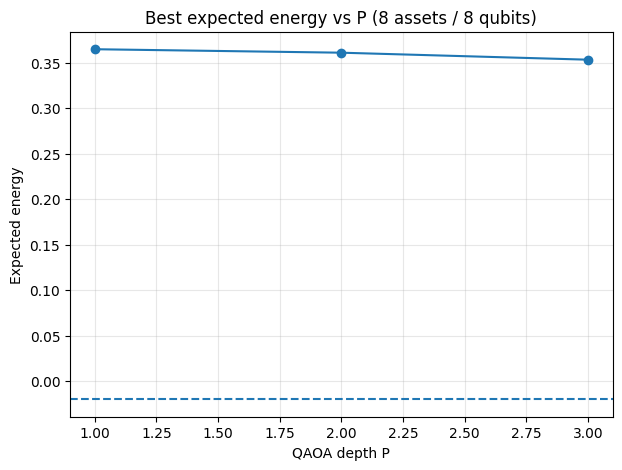

In [11]:
# =========================================================
# Plot 1: Expected energy vs P
# =========================================================

plot_df = summary_df.sort_values("P")

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["expected_energy"], marker="o")
plt.axhline(ground_truth_energy, linestyle="--")
plt.xlabel("QAOA depth P")
plt.ylabel("Expected energy")
plt.title("Best expected energy vs P (8 assets / 8 qubits)")
plt.grid(True, alpha=0.3)
plt.show()

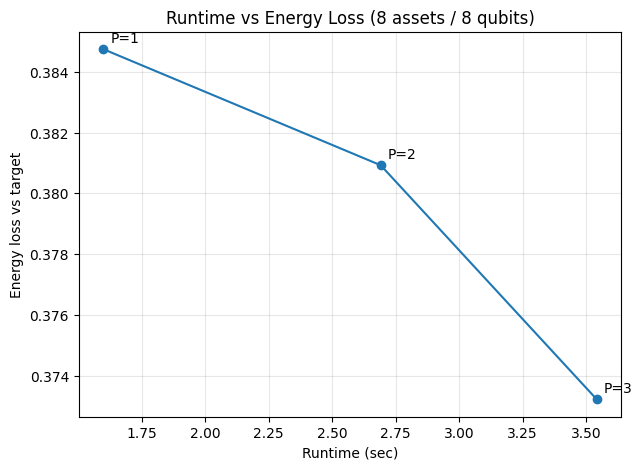

In [12]:
# =========================================================
# Plot 2: Runtime vs energy loss
# =========================================================

plot_df = summary_df.copy()

plt.figure(figsize=(7,5))
plt.plot(plot_df["runtime_sec"], plot_df["energy_gap_to_target"], marker="o")
for _, row in plot_df.iterrows():
    plt.annotate(
        f'P={int(row["P"])}',
        (row["runtime_sec"], row["energy_gap_to_target"]),
        xytext=(5,5),
        textcoords="offset points"
    )
plt.xlabel("Runtime (sec)")
plt.ylabel("Energy loss vs target")
plt.title("Runtime vs Energy Loss (8 assets / 8 qubits)")
plt.grid(True, alpha=0.3)
plt.show()

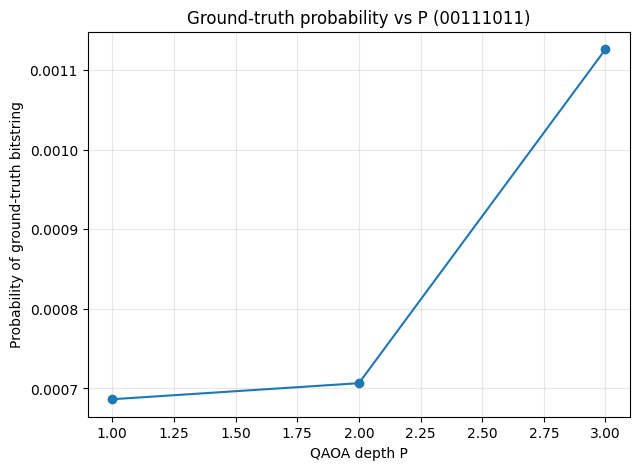

In [13]:
# =========================================================
# Plot 3: Ground-truth probability vs P
# =========================================================

plot_df = summary_df.sort_values("P")

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["ground_truth_probability"], marker="o")
plt.xlabel("QAOA depth P")
plt.ylabel("Probability of ground-truth bitstring")
plt.title(f"Ground-truth probability vs P ({ground_truth_bits})")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# =========================================================
# Best run by ground-truth probability
# Save this because it is useful for later plots too
# =========================================================

best_idx = max(
    range(len(experiment_results)),
    key=lambda i: experiment_results[i]["ground_truth_probability"]
)
best_run = experiment_results[best_idx]

print("Best run selected by ground-truth probability:")
print("P =", best_run["P"])
print("expected_energy =", best_run["expected_energy"])
print("ground_truth_probability =", best_run["ground_truth_probability"])
print("top_bitstring =", best_run["top_bitstring"])
print("top_probability =", best_run["top_probability"])
print("best_gamma =", best_run["best_gamma"])
print("best_beta =", best_run["best_beta"])

probs_opt = best_run["probs_opt"]

Best run selected by ground-truth probability:
P = 3
expected_energy = 0.3532371762197777
ground_truth_probability = 0.0011261607434006927
top_bitstring = 11001101
top_probability = 0.009815051493323271
best_gamma = [0.5747367542483983, -0.5058059751220882, 0.2769024462552142]
best_beta = [2.6081851330187757, 1.8994743872392952, -0.11610759726942335]


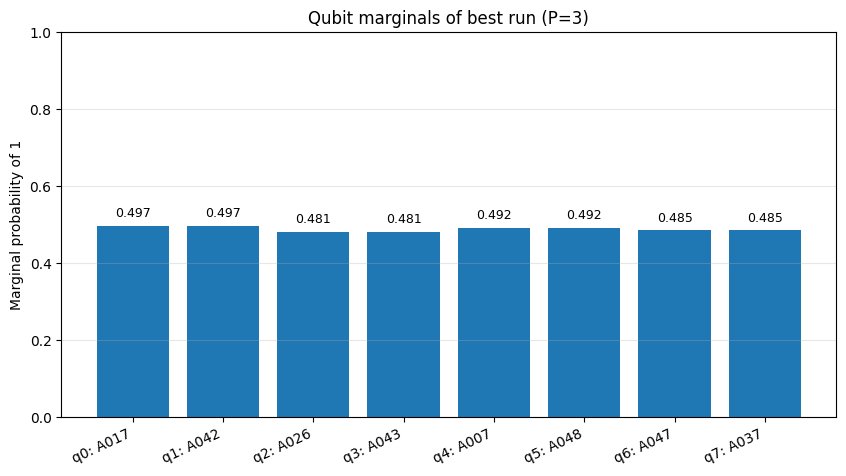

In [15]:
# =========================================================
# Qubit marginal probabilities for the best run
# =========================================================

marginals = np.zeros(n_qubits, dtype=float)

for idx, p in enumerate(probs_opt):
    bitstring = format(idx, f"0{n_qubits}b")
    for q in range(n_qubits):
        if bitstring[q] == "1":
            marginals[q] += p

qubit_labels = [
    "q0: A017",
    "q1: A042",
    "q2: A026",
    "q3: A043",
    "q4: A007",
    "q5: A048",
    "q6: A047",
    "q7: A037",
]

plt.figure(figsize=(10,5))
bars = plt.bar(range(n_qubits), marginals)

plt.xticks(range(n_qubits), qubit_labels, rotation=25, ha="right")
plt.ylabel("Marginal probability of 1")
plt.title(f"Qubit marginals of best run (P={best_run['P']})")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, marginals):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.015,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

In [16]:
# =========================================================
# Top measured bitstrings from best run
# =========================================================

top_k = 15
top_indices = np.argsort(probs_opt)[::-1][:top_k]

rows = []
for idx in top_indices:
    bitstring = format(idx, f"0{n_qubits}b")
    rows.append({
        "rank": len(rows) + 1,
        "bitstring": bitstring,
        "probability": float(probs_opt[idx]),
        "energy": ising_energy_from_bitstring(bitstring, J_base, h_base, ising_offset),
        "is_ground_truth": (bitstring == ground_truth_bits),
    })

top_df = pd.DataFrame(rows)
top_df

,rank,bitstring,probability,energy,is_ground_truth
0,1,11001101,0.009815,1.277052,False
1,2,11001110,0.009815,1.277126,False
2,3,11110000,0.009637,0.000650,False
3,4,00111000,0.009620,0.108624,False
4,5,00110100,0.009617,0.109318,False
5,6,11011100,0.009551,1.745088,False
6,7,11101100,0.009547,1.745482,False
7,8,10001011,0.009535,-0.007340,False
8,9,01001011,0.009535,-0.007296,False
9,10,10000111,0.009532,-0.006662,False


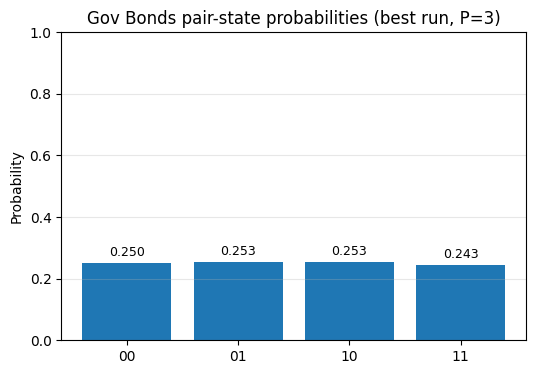

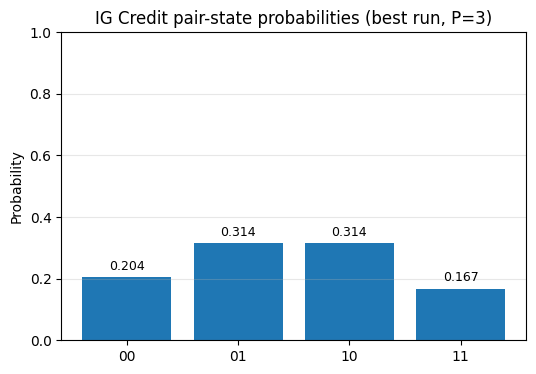

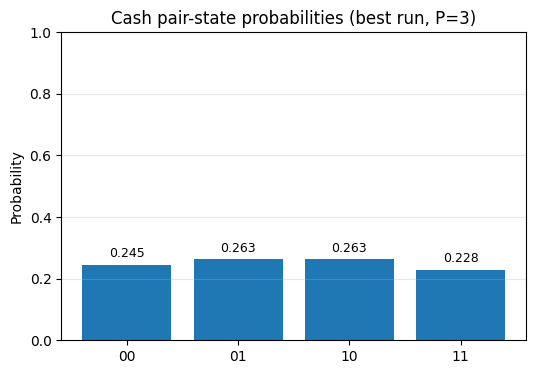

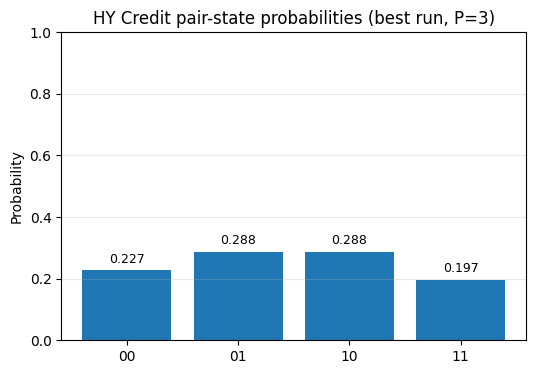

In [17]:
# =========================================================
# Optional: probability over each 2-qubit sector pair
# Just for inspection because Hartford sectors were chosen in pairs
# Pairs:
#   (0,1) Gov Bonds
#   (2,3) IG Credit
#   (4,5) Cash
#   (6,7) HY Credit
# =========================================================

pair_info = [
    ("Gov Bonds", (0,1)),
    ("IG Credit", (2,3)),
    ("Cash", (4,5)),
    ("HY Credit", (6,7)),
]

pair_state_labels = ["00", "01", "10", "11"]

for sector_name, (q1, q2) in pair_info:
    pair_probs = {state: 0.0 for state in pair_state_labels}

    for idx, p in enumerate(probs_opt):
        bitstring = format(idx, f"0{n_qubits}b")
        pair_state = bitstring[q1] + bitstring[q2]
        pair_probs[pair_state] += p

    vals = [pair_probs[s] for s in pair_state_labels]

    plt.figure(figsize=(6,4))
    bars = plt.bar(pair_state_labels, vals)
    plt.ylim(0, 1.0)
    plt.ylabel("Probability")
    plt.title(f"{sector_name} pair-state probabilities (best run, P={best_run['P']})")
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, vals):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.015,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.show()

In [18]:
# =========================================================
# Save important outputs for later reuse
# This is useful if later you want the same style of plots
# without rerunning everything
# =========================================================

saved_qaoa_outputs_8q = {
    "ground_truth_bits": ground_truth_bits,
    "ground_truth_energy": ground_truth_energy,
    "summary_df": summary_df.copy(),
    "best_run_P": best_run["P"],
    "best_gamma": best_run["best_gamma"],
    "best_beta": best_run["best_beta"],
    "best_expected_energy": best_run["expected_energy"],
    "best_ground_truth_probability": best_run["ground_truth_probability"],
    "best_top_bitstring": best_run["top_bitstring"],
    "best_top_probability": best_run["top_probability"],
    "probs_opt": probs_opt.copy(),
}

print("Saved outputs for later reuse.")
print("Best P:", saved_qaoa_outputs_8q["best_run_P"])

Saved outputs for later reuse.
Best P: 3


In [19]:
experiment_results_powell = run_qaoa_multiP([1, 2, 3], optimizer_name="Powell", maxiter=200)

summary_df_powell = pd.DataFrame([
    {
        "P": r["P"],
        "optimizer": r["optimizer"],
        "runtime_sec": r["runtime_sec"],
        "best_fun": r["best_fun"],
        "expected_energy": r["expected_energy"],
        "energy_gap_to_target": r["expected_energy"] - ground_truth_energy,
        "ground_truth_probability": r["ground_truth_probability"],
        "top_bitstring": r["top_bitstring"],
        "top_probability": r["top_probability"],
    }
    for r in experiment_results_powell
]).sort_values("P").reset_index(drop=True)

summary_df_powell

Running QAOA for P=1 with Powell
P=1
  expected_energy         = 0.382222004394
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.402217523184
  ground_truth_probability= 0.000116184047
  top_bitstring           = 11000111
  top_probability         = 0.008531681842
  runtime_sec             = 0.6748
Running QAOA for P=2 with Powell
P=2
  expected_energy         = 0.363770478300
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.383765997090
  ground_truth_probability= 0.000950327978
  top_bitstring           = 00110010
  top_probability         = 0.011071422095
  runtime_sec             = 4.0385
Running QAOA for P=3 with Powell
P=3
  expected_energy         = 0.343492810491
  target_energy           = -0.019995518790
  energy_gap_to_target    = 0.363488329281
  ground_truth_probability= 0.000634545208
  top_bitstring           = 11101100
  top_probability         = 0.011165120104
  runtime_sec             = 23.3230


,P,optimizer,runtime_sec,best_fun,expected_energy,energy_gap_to_target,ground_truth_probability,top_bitstring,top_probability
0,1,Powell,0.674825,0.382222,0.382222,0.402218,0.000116,11000111,0.008532
1,2,Powell,4.038534,0.363770,0.363770,0.383766,0.000950,00110010,0.011071
2,3,Powell,23.323006,0.343493,0.343493,0.363488,0.000635,11101100,0.011165


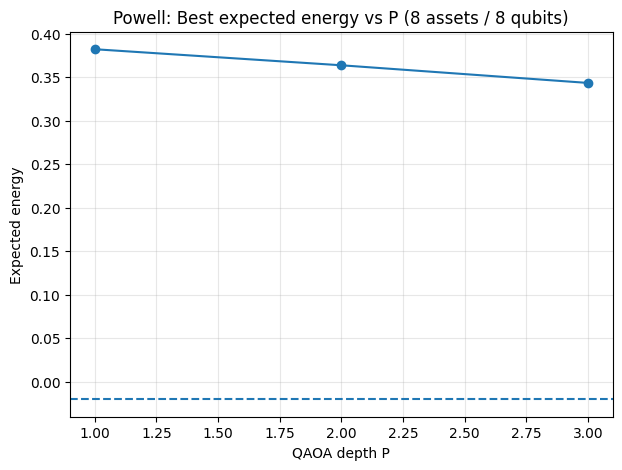

In [20]:
plot_df = summary_df_powell.sort_values("P")

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["expected_energy"], marker="o")
plt.axhline(ground_truth_energy, linestyle="--")
plt.xlabel("QAOA depth P")
plt.ylabel("Expected energy")
plt.title("Powell: Best expected energy vs P (8 assets / 8 qubits)")
plt.grid(True, alpha=0.3)
plt.show()

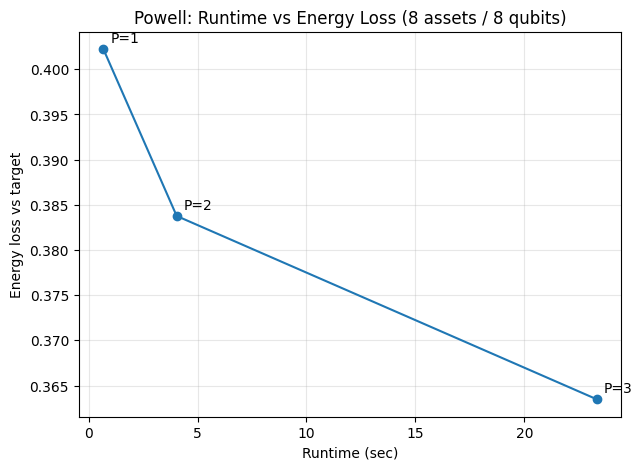

In [21]:
plot_df = summary_df_powell.copy()

plt.figure(figsize=(7,5))
plt.plot(plot_df["runtime_sec"], plot_df["energy_gap_to_target"], marker="o")

for _, row in plot_df.iterrows():
    plt.annotate(
        f'P={int(row["P"])}',
        (row["runtime_sec"], row["energy_gap_to_target"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Runtime (sec)")
plt.ylabel("Energy loss vs target")
plt.title("Powell: Runtime vs Energy Loss (8 assets / 8 qubits)")
plt.grid(True, alpha=0.3)
plt.show()

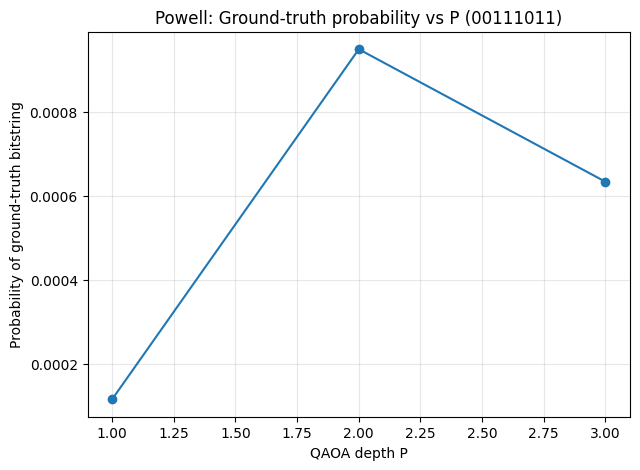

In [23]:
plot_df = summary_df_powell.sort_values("P")

plt.figure(figsize=(7,5))
plt.plot(plot_df["P"], plot_df["ground_truth_probability"], marker="o")
plt.xlabel("QAOA depth P")
plt.ylabel("Probability of ground-truth bitstring")
plt.title(f"Powell: Ground-truth probability vs P ({ground_truth_bits})")
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
best_idx_powell = max(
    range(len(experiment_results_powell)),
    key=lambda i: experiment_results_powell[i]["ground_truth_probability"]
)
best_run_powell = experiment_results_powell[best_idx_powell]
probs_opt_powell = best_run_powell["probs_opt"]

print("Best Powell run selected by ground-truth probability:")
print("P =", best_run_powell["P"])
print("expected_energy =", best_run_powell["expected_energy"])
print("ground_truth_probability =", best_run_powell["ground_truth_probability"])
print("top_bitstring =", best_run_powell["top_bitstring"])
print("top_probability =", best_run_powell["top_probability"])
print("best_gamma =", best_run_powell["best_gamma"])
print("best_beta =", best_run_powell["best_beta"])

Best Powell run selected by ground-truth probability:
P = 2
expected_energy = 0.3637704782997004
ground_truth_probability = 0.000950327977687732
top_bitstring = 00110010
top_probability = 0.011071422094877529
best_gamma = [-0.7629297301932785, -2.643698071286967]
best_beta = [0.24006581083425926, 0.07045822826234194]


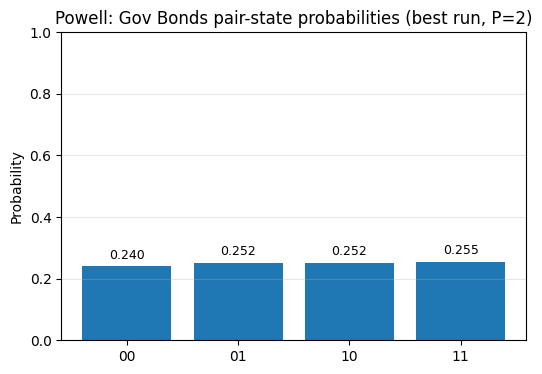

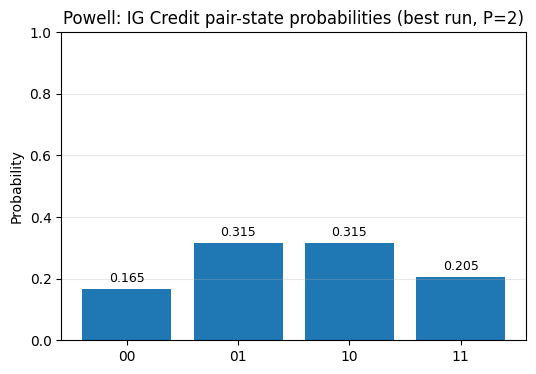

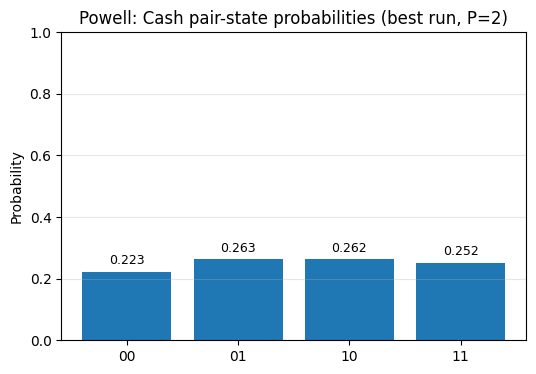

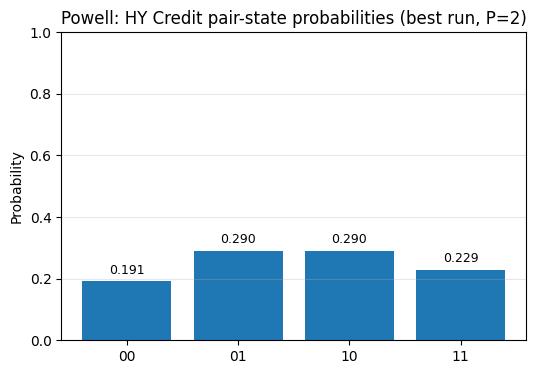

In [25]:
pair_info = [
    ("Gov Bonds", (0,1)),
    ("IG Credit", (2,3)),
    ("Cash", (4,5)),
    ("HY Credit", (6,7)),
]

pair_state_labels = ["00", "01", "10", "11"]

for sector_name, (q1, q2) in pair_info:
    pair_probs = {state: 0.0 for state in pair_state_labels}

    for idx, p in enumerate(probs_opt_powell):
        bitstring = format(idx, f"0{n_qubits}b")
        pair_state = bitstring[q1] + bitstring[q2]
        pair_probs[pair_state] += p

    vals = [pair_probs[s] for s in pair_state_labels]

    plt.figure(figsize=(6,4))
    bars = plt.bar(pair_state_labels, vals)
    plt.ylim(0, 1.0)
    plt.ylabel("Probability")
    plt.title(f"Powell: {sector_name} pair-state probabilities (best run, P={best_run_powell['P']})")
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, vals):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.015,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.show()

In [26]:
top_k = 15
top_indices_powell = np.argsort(probs_opt_powell)[::-1][:top_k]

rows_powell = []
for idx in top_indices_powell:
    bitstring = format(idx, f"0{n_qubits}b")
    rows_powell.append({
        "rank": len(rows_powell) + 1,
        "bitstring": bitstring,
        "probability": float(probs_opt_powell[idx]),
        "energy": ising_energy_from_bitstring(bitstring, J_base, h_base, ising_offset),
        "is_ground_truth": (bitstring == ground_truth_bits),
    })

top_df_powell = pd.DataFrame(rows_powell)
top_df_powell

,rank,bitstring,probability,energy,is_ground_truth
0,1,00110010,0.011071,0.887398,False
1,2,00110001,0.011071,0.887328,False
2,3,11000111,0.010784,0.269866,False
3,4,11001011,0.010779,0.269180,False
4,5,00001111,0.010588,-0.012132,False
5,6,01110100,0.010263,0.065790,False
6,7,10110100,0.010262,0.065730,False
7,8,01111000,0.010258,0.065088,False
8,9,10111000,0.010257,0.065040,False
9,10,11101100,0.010060,1.745482,False
